In [2]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 15.9 MB/s eta 0:00:00


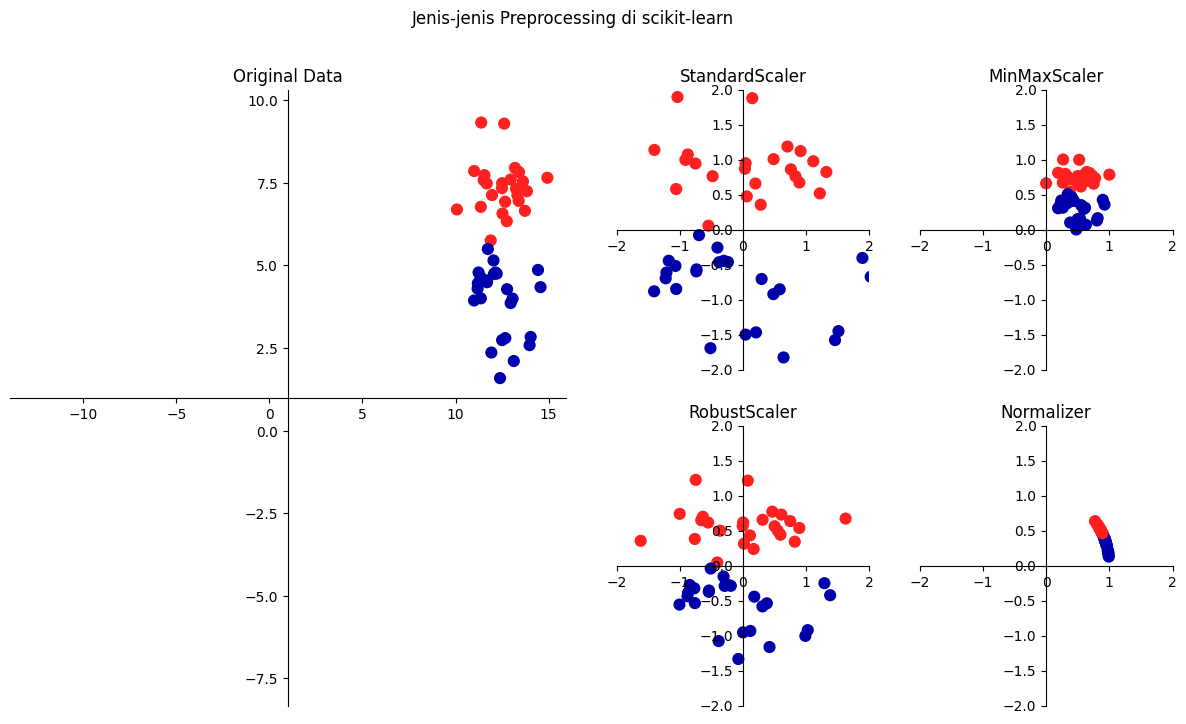

In [3]:
import mglearn
import matplotlib.pyplot as plt

mglearn.plots.plot_scaling()
plt.suptitle("Jenis-jenis Preprocessing di scikit-learn")
plt.show()

Kode ini memvisualisasikan empat cara utama untuk menskalakan data: StandardScaler (rata-rata 0, varians 1), MinMaxScaler (rentang 0-1), RobustScaler (menggunakan median dan kuartil untuk menangani outlier), dan Normalizer (memproyeksikan data ke lingkaran satuan)

** Memuat Dataset untuk Preprocessing**

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=1)

print(f"Ukuran training set: {X_train.shape}")
print(f"Ukuran test set: {X_test.shape}")

Ukuran training set: (426, 30)
Ukuran test set: (143, 30)


Dataset Breast Cancer yang memiliki 30 fitur dengan skala yang sangat berbeda-beda untuk mendemonstrasikan pentingnya preprocessing


**Inisialisasi MinMaxScaler**

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

Mengimpor kelas MinMaxScaler dan membuat objek (instansiasi). Objek ini nantinya akan menghitung nilai minimum dan maksimum dari setiap fitur

** Menghitung Parameter Scaling (Fitting)**

In [6]:
scaler.fit(X_train)

MinMaxScaler()

Metode fit pada scaler hanya membutuhkan data input (X_train). Di sini, scaler mempelajari nilai minimum dan maksimum dari setiap kolom di training set

**Menerapkan Transformasi pada Data Training**

In [7]:
X_train_scaled = scaler.transform(X_train)

Setelah "belajar" lewat fit, kita menggunakan transform untuk benar-benar menggeser dan mengubah skala data training asli ke dalam rentang 0 hingga 1

**Memeriksa Hasil Scaling**

In [8]:
print(f"Bentuk data setelah ditransformasi: {X_train_scaled.shape}")
print(f"Nilai minimal per fitur: {X_train_scaled.min(axis=0)}")
print(f"Nilai maksimal per fitur: {X_train_scaled.max(axis=0)}")

Bentuk data setelah ditransformasi: (426, 30)
Nilai minimal per fitur: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Nilai maksimal per fitur: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


**Menerapkan Transformasi pada Data Test**

In [9]:
X_test_scaled = scaler.transform(X_test)

Memanggil transform(X_test), bukan fit(X_test)

**Memeriksa Rentang Data Test Setelah Scaling**

In [10]:
print(f"Nilai minimal fitur data test: {X_test_scaled.min(axis=0)}")
print(f"Nilai maksimal fitur data test: {X_test_scaled.max(axis=0)}")

Nilai minimal fitur data test: [ 0.0336031   0.0226581   0.03144219  0.01141039  0.14128374  0.04406704
  0.          0.          0.1540404  -0.00615249 -0.00137796  0.00594501
  0.00430665  0.00079567  0.03919502  0.0112206   0.          0.
 -0.03191387  0.00664013  0.02660975  0.05810235  0.02031974  0.00943767
  0.1094235   0.02637792  0.          0.         -0.00023764 -0.00182032]
Nilai maksimal fitur data test: [0.9578778  0.81501522 0.95577362 0.89353128 0.81132075 1.21958701
 0.87956888 0.9333996  0.93232323 1.0371347  0.42669616 0.49765736
 0.44117231 0.28371044 0.48703131 0.73863671 0.76717172 0.62928585
 1.33685792 0.39057253 0.89612238 0.79317697 0.84859804 0.74488793
 0.9154725  1.13188961 1.07008547 0.92371134 1.20532319 1.63068851]


**Menggunakan Shortcut fit_transform**

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

Hampir semua transformer di scikit-learn memiliki metode fit_transform yang melakukan fitting dan transformasi dalam satu langkah efisien

**Dampak Scaling pada Model SVM (Tanpa Scaling)**

In [12]:
from sklearn.svm import SVC
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

svm = SVC(C=100)
svm.fit(X_train, y_train)
print(f"Akurasi test set (tanpa scaling): {svm.score(X_test, y_test):.2f}")

Akurasi test set (tanpa scaling): 0.94


Tanpa scaling, SVM biasanya bekerja sangat buruk pada data dengan rentang fitur yang jauh berbeda. Akurasinya mungkin tidak memuaskan


**Dampak Scaling pada Model SVM (Dengan Scaling)**

In [13]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm.fit(X_train_scaled, y_train)
print(f"Akurasi test set (dengan scaling): {svm.score(X_test_scaled, y_test):.2f}")

Akurasi test set (dengan scaling): 0.97


Dengan hanya menerapkan MinMaxScaler, akurasi SVM meningkat drastis (mendekati 97%). Ini membuktikan preprocessing adalah kunci sukses banyak algoritma

**Principal Component Analysis (PCA) untuk Visualisasi**

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaler.fit(cancer.data)
X_scaled = scaler.transform(cancer.data)

pca = PCA(n_components=2)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

print(f"Shape data asli: {X_scaled.shape}")
print(f"Shape setelah PCA: {X_pca.shape}")

Shape data asli: (569, 30)
Shape setelah PCA: (569, 2)


PCA merotasi dataset dan membuang komponen dengan varians rendah. Di sini kita mengurangi 30 fitur menjadi hanya 2 komponen utama untuk visualisasi

**Visualisasi Dua Komponen Utama PCA**

Text(0, 0.5, 'Second principal component')

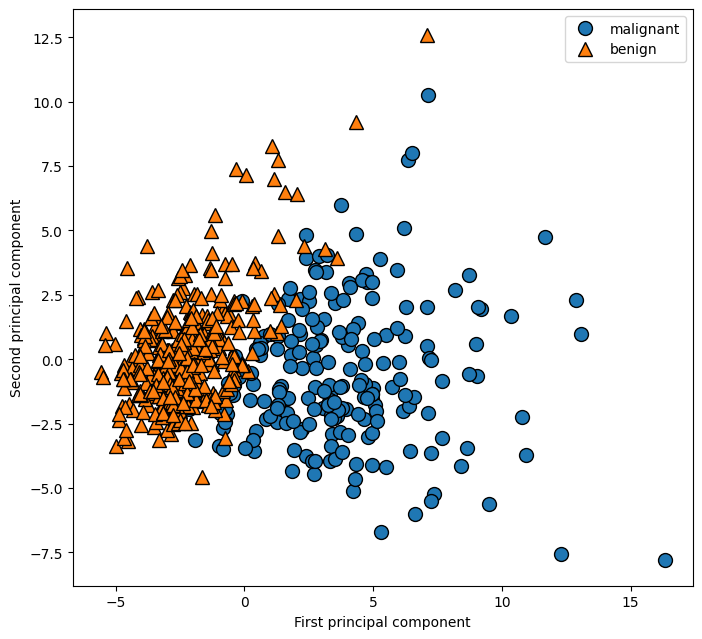

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
mglearn.discrete_scatter(X_pca[:, 0], X_pca[:, 1], cancer.target)
plt.legend(cancer.target_names, loc="best")
plt.gca().set_aspect("equal")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")

Grafik ini menunjukkan bahwa meskipun PCA tidak tahu label kelas, ia berhasil memisahkan kelas tumor ganas dan jinak secara visual hanya dari korelasi fitur

**Memeriksa Atribut Komponen PCA**

In [16]:
print(f"PCA component shape: {pca.components_.shape}")

PCA component shape: (2, 30)


Baris dalam atribut components_ merepresentasikan komponen utama, sedangkan kolomnya sesuai dengan 30 fitur asli dataset

**Heatmap Komponen PCA**

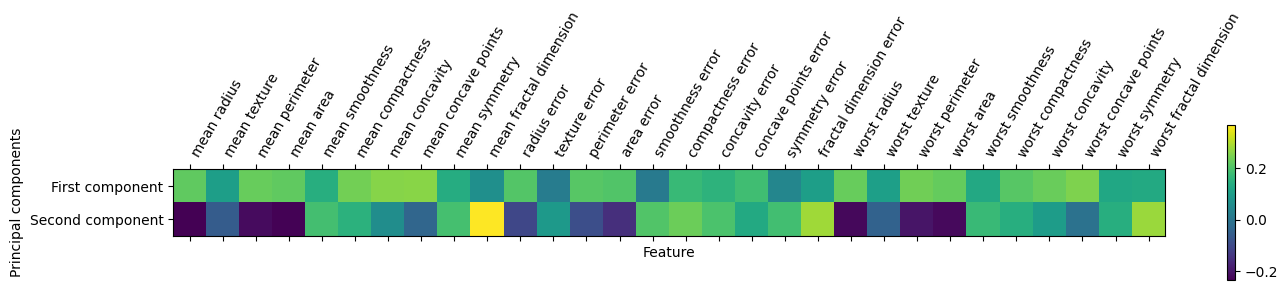

In [18]:
plt.matshow(pca.components_, cmap='viridis')

plt.yticks([0, 1], ["First component", "Second component"])

plt.colorbar()

plt.xticks(
    range(len(cancer.feature_names)),
    cancer.feature_names,
    rotation=60,
    ha='left'
)

plt.xlabel("Feature")
plt.ylabel("Principal components")

plt.show()

**Non-Negative Matrix Factorization (NMF)**

In [19]:
from sklearn.decomposition import NMF
nmf = NMF(n_components=15, random_state=0, max_iter=1000)
nmf.fit(X_train_scaled) # NMF memerlukan data non-negatif
X_nmf = nmf.transform(X_train_scaled)
print(f"Shape setelah NMF: {X_nmf.shape}")

Shape setelah NMF: (426, 15)


NMF mengekstrak komponen yang bersifat aditif (hanya positif). Sangat berguna untuk data suara atau wajah karena menghasilkan bagian-bagian yang lebih bisa diinterpretasikan daripada PCA

**k-Means Clustering**

In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, y = make_blobs(random_state=1)
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

print(f"Prediksi cluster: {kmeans.labels_}")

Prediksi cluster: [1 0 0 0 2 2 2 0 1 1 0 0 2 1 2 2 2 1 0 0 2 0 2 1 0 2 2 1 1 2 1 1 2 1 0 2 0
 0 0 2 2 0 1 0 0 2 1 1 1 1 0 2 2 2 1 2 0 0 1 1 0 2 2 0 0 2 1 2 1 0 0 0 2 1
 1 0 2 2 1 0 1 0 0 2 1 1 1 1 0 1 2 1 1 0 0 2 2 1 2 1]


 k-Means mencari pusat massa (centroid) dan memasukkan setiap titik ke cluster terdekat


**Visualisasi k-Means**

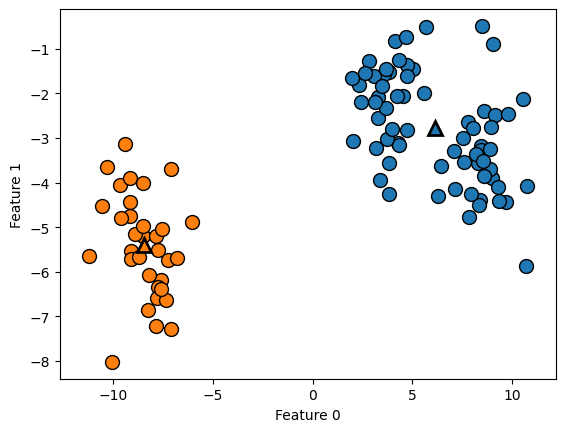

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn

from sklearn.cluster import KMeans

# Membuat dataset contoh
X, y = mglearn.datasets.make_blobs()

# Membuat model K-Means dengan 2 cluster
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X)

# Menampilkan data berdasarkan cluster
mglearn.discrete_scatter(
    X[:, 0],
    X[:, 1],
    kmeans.labels_,
    markers='o'
)

# Menampilkan pusat cluster (centroid)
mglearn.discrete_scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    [0, 1],
    markers='^',
    markeredgewidth=2
)

plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

Lingkaran adalah data points dan segitiga adalah pusat cluster (centroid) yang ditemukan algoritma


**Agglomerative Clustering (Dendrogram)**

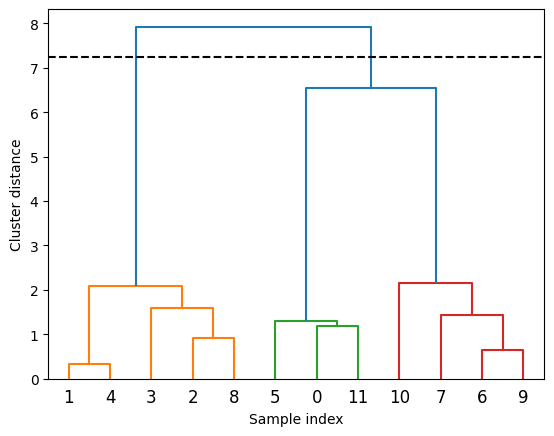

In [11]:
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, ward
import matplotlib.pyplot as plt

X, y = make_blobs(random_state=0, n_samples=12)

linkage_array = ward(X)

dendrogram(linkage_array)

ax = plt.gca()
bounds = ax.get_xbound()

ax.plot(bounds, [7.25, 7.25], '--', c='k')
ax.plot(bounds, [27, 27], '--', c='k')

plt.xlabel("Sample index")
plt.ylabel("Cluster distance")
plt.show()

Dendrogram membantu kita memvisualisasikan penggabungan cluster secara hierarkis dan menentukan jumlah cluster yang tepat berdasarkan jarak

** DBSCAN Clustering**

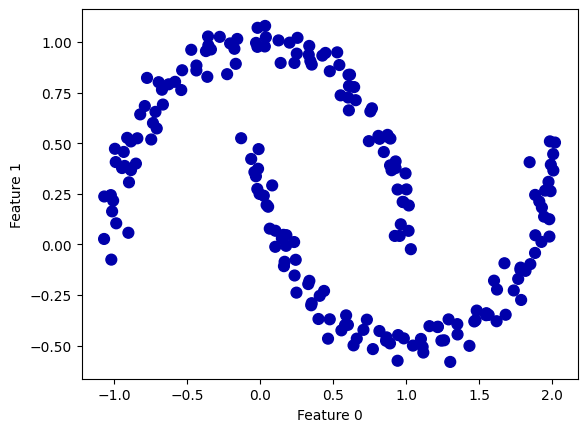

In [13]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import mglearn

X, y = make_moons(
    n_samples=200,
    noise=0.05,
    random_state=0
)

dbscan = DBSCAN()

clusters = dbscan.fit_predict(X)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=clusters,
    cmap=mglearn.cm2,
    s=60
)

plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

DBSCAN sangat hebat karena bisa menemukan cluster dengan bentuk kompleks (seperti bulan sabit) tanpa kita harus menentukan jumlah clusternya terlebih dahulu


**Evaluasi Clustering dengan Adjusted Rand Index (ARI)**

In [14]:
from sklearn.metrics import adjusted_rand_score
# Bandingkan hasil DBSCAN tadi dengan label y yang asli (ground truth)
print(f"Skor ARI: {adjusted_rand_score(y, clusters):.2f}")

Skor ARI: 0.00


RI memberikan skor antara 0 (acak) dan 1 (sempurna) untuk mengevaluasi seberapa mirip hasil clustering dengan label asli yang kita miliki
